# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, SimpleRNN
from tensorflow.keras.optimizers import Adam

### 1.1 Generating dataset

In [42]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [43]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [44]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [45]:
no_training_epochs = 5

### 1.3 Data examination

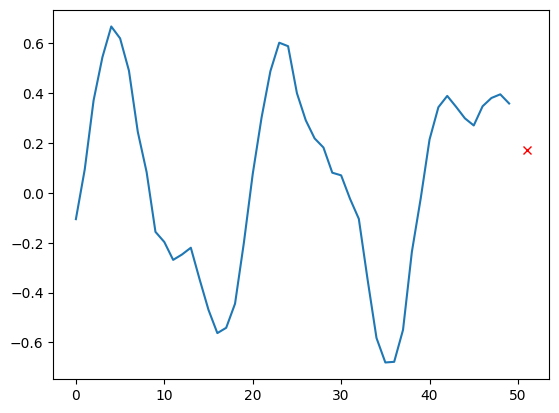

In [13]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [46]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

In [47]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [16]:
model_linear.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0627 - mean_squared_error: 0.0627 - val_loss: 0.0298 - val_mean_squared_error: 0.0298
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0210 - mean_squared_error: 0.0210 - val_loss: 0.0148 - val_mean_squared_error: 0.0148
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0103 - val_mean_squared_error: 0.0103
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0084 - val_mean_squared_error: 0.0084
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0072 - val_mean_squared_error: 0.0072


In [18]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

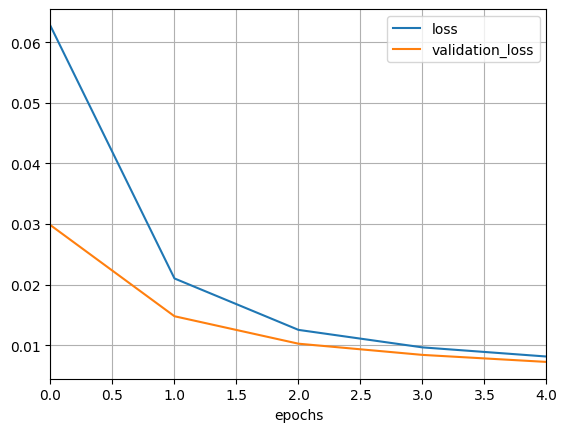

In [19]:
plot_function(history_linear)

In [20]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.007208426482975483
Test MSE:  0.007208426482975483


### 1.5 Simple RNN Model

In [48]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [49]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [23]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4545 - mean_squared_error: 0.4545 - val_loss: 0.4318 - val_mean_squared_error: 0.4318
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4051 - mean_squared_error: 0.4051 - val_loss: 0.3866 - val_mean_squared_error: 0.3866
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3604 - mean_squared_error: 0.3604 - val_loss: 0.3428 - val_mean_squared_error: 0.3428
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3175 - mean_squared_error: 0.3175 - val_loss: 0.3001 - val_mean_squared_error: 0.3001
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2765 - mean_squared_error: 0.2765 - val_loss: 0.2595 - val_mean_squared_error: 0.2595


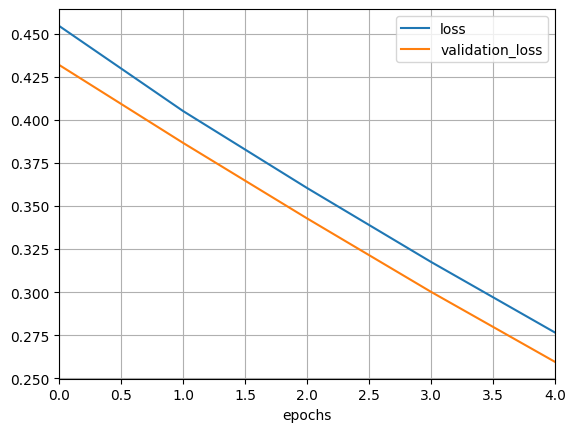

In [24]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [50]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [51]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [27]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0433 - mean_squared_error: 0.0433 - val_loss: 0.0068 - val_mean_squared_error: 0.0068
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0041 - val_mean_squared_error: 0.0041
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0037 - val_mean_squared_error: 0.0037
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0034 - mean_squared_error: 0.0034 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0031 - val_mean_squared_error: 0.0031


In [28]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0031729256734251976
Test MSE:  0.0031729256734251976


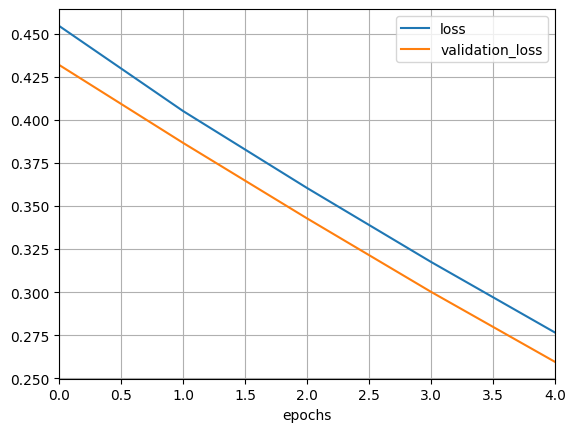

In [29]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow import keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

### 2.1 - Load dataset

In [13]:
vocabulary_size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

### 2.2 - Dataset examination

In [3]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [5]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <unk> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <unk> to the two little boy's that played the <unk> of norman and paul they were just brilliant children are often left out of the <unk> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what

In [14]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [15]:
embed_size = 256


def build_model(core_type, vocabulary_size, embed_size):
    model = keras.models.Sequential([
        keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
        core_type(128, return_sequences=True),
        core_type(128),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [16]:
experiments = [
    ("SimpleRNN", keras.layers.SimpleRNN),
    ("LSTM", keras.layers.LSTM),
    ("GRU", keras.layers.GRU)
]

results = []
histories = {}

In [17]:
for name, core_layer in experiments:
    model = build_model(core_layer, vocabulary_size, embed_size)
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    print(f"\nTraining {name}...")
    history = model.fit(X_train, y_train, epochs=5, validation_split=0.2, verbose=1)
    histories[name] = history

    score = model.evaluate(X_test, y_test, verbose=0)
    results.append({
        'Model': name,
        'Test Loss': float(score[0]),
        'Test Accuracy (%)': float(score[1] * 100),
        'Best Val Accuracy (%)': float(max(history.history['val_accuracy']) * 100)
    })


Training SimpleRNN...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.4994 - loss: 0.7038 - val_accuracy: 0.4938 - val_loss: 0.6937
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5049 - loss: 0.6953 - val_accuracy: 0.4938 - val_loss: 0.6964
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4985 - loss: 0.6956 - val_accuracy: 0.4938 - val_loss: 0.6937
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5256 - loss: 0.6915 - val_accuracy: 0.4940 - val_loss: 0.7024
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.6104 - loss: 0.6520 - val_accuracy: 0.5988 - val_loss: 0.6715

Training LSTM...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.6057 - loss: 0.6524 - val_accuracy: 0.5224 - val_loss: 0.6831
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5840 - loss: 0.6663 - val_accuracy: 0.7794 - val_loss: 0.5006
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - a

In [18]:
results_sorted = sorted(results, key=lambda x: x['Test Accuracy (%)'], reverse=True)

print('\nComparison of recurrent cores on IMDb sentiment dataset:')
for item in results_sorted:
    print(
        f"{item['Model']:>9} | "
        f"Test Acc: {item['Test Accuracy (%)']:.2f}% | "
        f"Best Val Acc: {item['Best Val Accuracy (%)']:.2f}% | "
        f"Test Loss: {item['Test Loss']:.4f}"
    )


Comparison of recurrent cores on IMDb sentiment dataset:
      GRU | Test Acc: 82.89% | Best Val Acc: 85.68% | Test Loss: 0.6493
     LSTM | Test Acc: 82.53% | Best Val Acc: 85.74% | Test Loss: 0.4614
SimpleRNN | Test Acc: 59.39% | Best Val Acc: 59.88% | Test Loss: 0.6790


In [19]:
best_model = results_sorted[0]['Model']
print(f"\nBest performing recurrent core: {best_model}")


Best performing recurrent core: GRU


TASK: Modify structure, change the core of the network from RNN to LSTM and GRU. Compare the results.